In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from early_stopping import EarlyStopping

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
# Transformaciones SOLO para ENTRENAMIENTO
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para VALIDACIÓN y PRUEBA
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# root debe apuntar a la carpeta data en la raiz del proyecto
full_dataset = datasets.ImageFolder(
    root="../data/eurosat"
)

dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [20]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32)

test_loader = DataLoader(test_dataset, batch_size=32)

In [21]:
print(f"Tamaño del dataset de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del dataset de validación: {len(val_dataset)}")
print(f"Tamaño del dataset de prueba: {len(test_dataset)}")

sample_data, sample_label = next(iter(train_loader))
print(f"Forma de un batch de entrenamiento: {sample_data.shape}")

Tamaño del dataset de entrenamiento: 18900
Tamaño del dataset de validación: 4050
Tamaño del dataset de prueba: 4050
Forma de un batch de entrenamiento: torch.Size([32, 3, 224, 224])


In [22]:
model = models.resnet50(pretrained=True)

In [23]:
for param in model.parameters():
    param.requires_grad = False

In [24]:
model.fc = nn.Linear(model.fc.in_features, 10)

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=4)

In [26]:
model = model.to(device)

In [27]:
epochs = 20
best_val_acc = 0

for epoch in range(epochs):

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_acc += (preds == labels).sum().item()
    val_acc /= len(val_loader.dataset)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        #torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch}: NEW RECORD! {val_acc:.4f}")

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}: Val Acc = {val_acc:.4f}, LR = {current_lr}")

    scheduler.step(val_acc)

    early_stopping(val_acc)
    if early_stopping.early_stop:
        print("Early stopping activated")
        print(f"Best accuracy achieved: {best_val_acc:.4f}")
        break


Epoch 0: NEW RECORD! 0.9094
Epoch 0: Val Acc = 0.9094, LR = 0.001
Epoch 1: NEW RECORD! 0.9133
Epoch 1: Val Acc = 0.9133, LR = 0.001
Epoch 2: NEW RECORD! 0.9299
Epoch 2: Val Acc = 0.9299, LR = 0.001
Epoch 3: NEW RECORD! 0.9405
Epoch 3: Val Acc = 0.9405, LR = 0.001
Epoch 4: Val Acc = 0.9356, LR = 0.001
EarlyStopping counter: 1 out of 4
Epoch 5: Val Acc = 0.9235, LR = 0.001
EarlyStopping counter: 2 out of 4
Epoch 6: Val Acc = 0.9316, LR = 0.001
EarlyStopping counter: 3 out of 4
Epoch 7: Val Acc = 0.9400, LR = 0.001
EarlyStopping counter: 4 out of 4
Early stopping activated
Best accuracy achieved: 0.9405


In [28]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print("Test accuracy:", accuracy)

Test accuracy: 0.9367901234567901


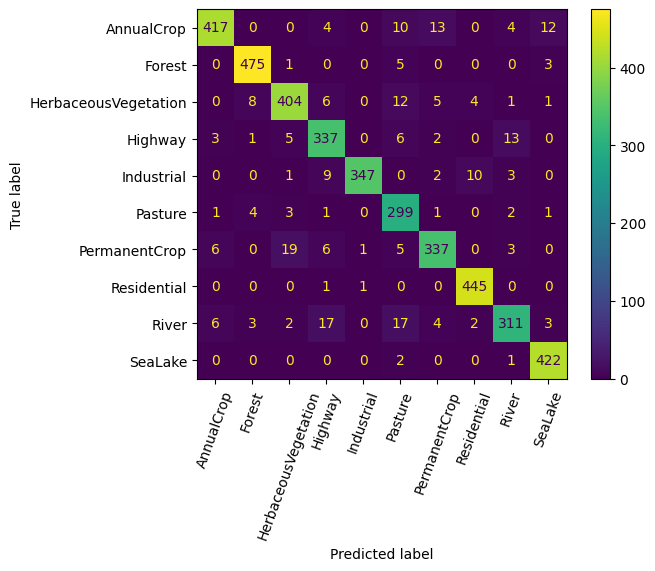

In [29]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.dataset.classes
)

disp.plot(xticks_rotation=70)
plt.show()

In [30]:
# guardamos el modelo entrenado
torch.save(model.state_dict(), 'resnet50_model.pth')